**Lab 3-Tasks**  
**Course: ANN** 

**Khair ul wara Hussain**
**Student Id: FA23-BAI-022**

### Lab Task 1: Dataset Loading and Visualization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

data = load_breast_cancer()
X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print("Dataset shape:", df.shape)
print("Feature names:", list(data.feature_names))
print("Target classes:", list(data.target_names))
print("Missing values:", df.isnull().sum().sum())

Dataset shape: (569, 31)
Feature names: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension')]
Target classes: [np.str_('malignant'), np.str_('benign')]
Missing values: 0


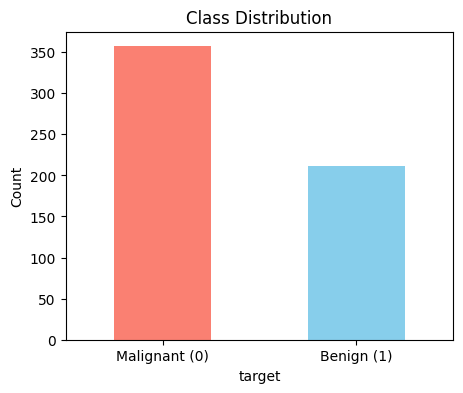

In [2]:
plt.figure(figsize=(5,4))
df['target'].value_counts().plot(kind='bar', color=['salmon','skyblue'])
plt.xticks([0,1], ['Malignant (0)','Benign (1)'], rotation=0)
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_train = np.where(y_train == 0, -1, 1)
y_test = np.where(y_test == 0, -1, 1)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


### Lab Task 2: Basic Perceptron Implementation

In [4]:
class Perceptron:
    def __init__(self, n_features, lr=0.01, epochs=50, init='random', seed=42):
        rng = np.random.default_rng(seed)
        if init == 'zeros':
            self.weights = np.zeros(n_features)
        elif init == 'random':
            self.weights = rng.uniform(-0.5, 0.5, n_features)
        elif init == 'gaussian':
            self.weights = rng.normal(0, 0.01, n_features)
        elif init == 'xavier':
            limit = np.sqrt(6 / (n_features + 1))
            self.weights = rng.uniform(-limit, limit, n_features)
        elif init == 'he':
            self.weights = rng.normal(0, np.sqrt(2 / n_features), n_features)
        elif init == 'orthogonal':
            a = rng.normal(0, 1, (n_features, n_features))
            q, _ = np.linalg.qr(a)
            self.weights = q[0]
        else:
            raise ValueError('Unknown init type')

        self.bias = 0.0
        self.lr = lr
        self.epochs = epochs
        self.errors_ = []
        self.converge_epoch = epochs

    def net_input(self, X):
        return np.dot(X, self.weights) + self.bias

    def predict(self, X):
        return np.where(self.net_input(X) >= 0, 1, -1)

    def fit(self, X, y):
        for epoch in range(self.epochs):
            errors = 0
            for xi, target in zip(X, y):
                pred = self.predict(xi.reshape(1, -1))[0]
                update = self.lr * (target - pred)
                if update != 0:
                    self.weights += update * xi
                    self.bias += update
                    errors += 1
            self.errors_.append(errors)
            if errors == 0 and self.converge_epoch == self.epochs:
                self.converge_epoch = epoch + 1
        return self

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

In [5]:
ppn = Perceptron(n_features=X_train.shape[1], lr=0.01, epochs=50, init='random', seed=1)
ppn.fit(X_train, y_train)

acc = ppn.accuracy(X_test, y_test)
print("Test accuracy:", acc)

Test accuracy: 0.9649122807017544


### Lab Task 3: Perceptron Learning Curve and Weight Visualization

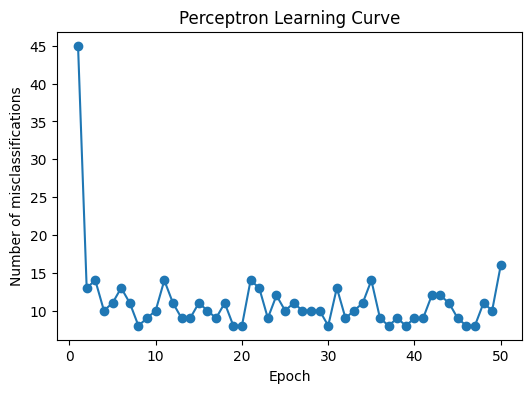

Final weights: [-0.17670597  0.05587942 -0.5256867   0.20790895 -0.06387622  0.3704264
 -0.02432165 -0.27167693  0.10378226 -0.22289985 -0.22999579  0.06467609
 -0.21305771 -0.18542472 -0.19686045 -0.03383189  0.3389295   0.0433982
  0.02356299  0.05575768 -0.06748131 -0.44715697 -0.23136569  0.10038355
 -0.04222599  0.05509474 -0.50371256 -0.28459665 -0.37933513  0.32106912]
Final bias: 0.019999999999999993


In [6]:
plt.figure(figsize=(6,4))
plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Number of misclassifications')
plt.title('Perceptron Learning Curve')
plt.show()

print("Final weights:", ppn.weights)
print("Final bias:", ppn.bias)

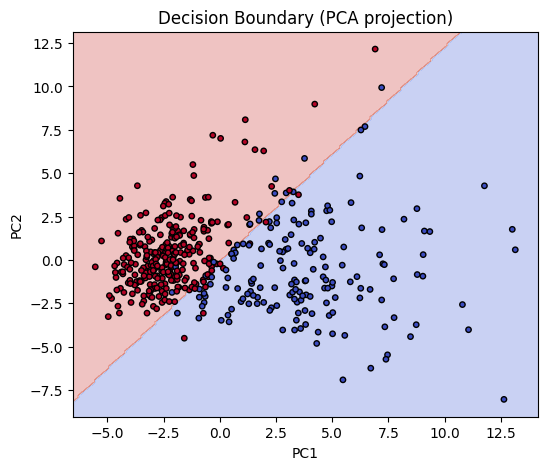

In [7]:
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)

ppn_2d = Perceptron(n_features=2, lr=0.01, epochs=50, init='random', seed=1)
ppn_2d.fit(X_train_2d, y_train)

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = ppn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', s=15)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Decision Boundary (PCA projection)')
plt.show()

### Lab Task 4: Gaussian Weight Initialization

Default init - epochs to converge: 50
Gaussian init - epochs to converge: 50
Gaussian init - test accuracy: 0.9736842105263158


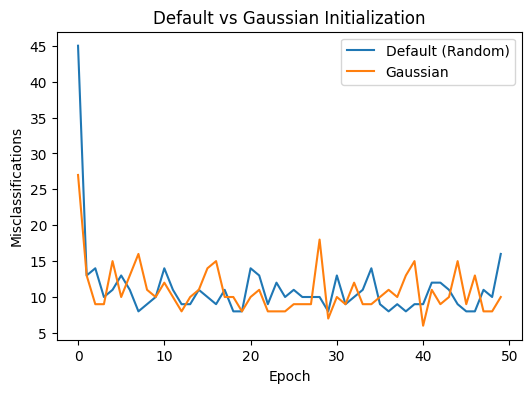

In [8]:
gaussian_ppn = Perceptron(n_features=X_train.shape[1], lr=0.01, epochs=50, init='gaussian', seed=1)
gaussian_ppn.fit(X_train, y_train)

print("Default init - epochs to converge:", ppn.converge_epoch)
print("Gaussian init - epochs to converge:", gaussian_ppn.converge_epoch)
print("Gaussian init - test accuracy:", gaussian_ppn.accuracy(X_test, y_test))

plt.figure(figsize=(6,4))
plt.plot(ppn.errors_, label='Default (Random)')
plt.plot(gaussian_ppn.errors_, label='Gaussian')
plt.xlabel('Epoch')
plt.ylabel('Misclassifications')
plt.legend()
plt.title('Default vs Gaussian Initialization')
plt.show()

### Lab Task 5: Xavier/Glorot Initialization

Xavier init - epochs to converge: 50
Xavier init - test accuracy: 0.9736842105263158


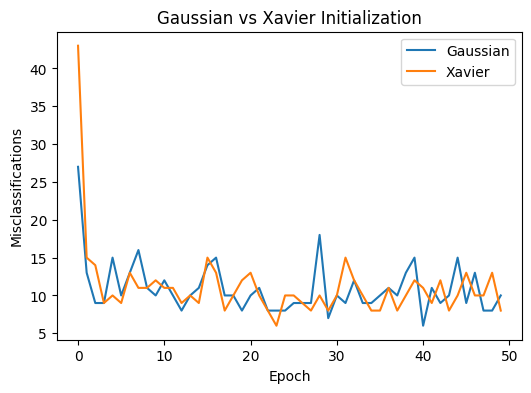

In [9]:
xavier_ppn = Perceptron(n_features=X_train.shape[1], lr=0.01, epochs=50, init='xavier', seed=1)
xavier_ppn.fit(X_train, y_train)

print("Xavier init - epochs to converge:", xavier_ppn.converge_epoch)
print("Xavier init - test accuracy:", xavier_ppn.accuracy(X_test, y_test))

plt.figure(figsize=(6,4))
plt.plot(gaussian_ppn.errors_, label='Gaussian')
plt.plot(xavier_ppn.errors_, label='Xavier')
plt.xlabel('Epoch')
plt.ylabel('Misclassifications')
plt.legend()
plt.title('Gaussian vs Xavier Initialization')
plt.show()

### Lab Task 6: He/Kaiming Initialization

He init - epochs to converge: 50
He init - test accuracy: 0.956140350877193


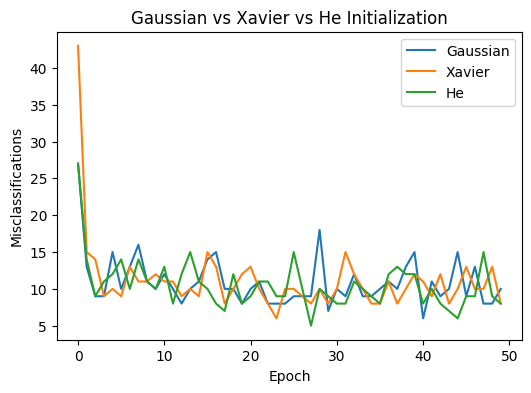

In [10]:
he_ppn = Perceptron(n_features=X_train.shape[1], lr=0.01, epochs=50, init='he', seed=1)
he_ppn.fit(X_train, y_train)

print("He init - epochs to converge:", he_ppn.converge_epoch)
print("He init - test accuracy:", he_ppn.accuracy(X_test, y_test))

plt.figure(figsize=(6,4))
plt.plot(gaussian_ppn.errors_, label='Gaussian')
plt.plot(xavier_ppn.errors_, label='Xavier')
plt.plot(he_ppn.errors_, label='He')
plt.xlabel('Epoch')
plt.ylabel('Misclassifications')
plt.legend()
plt.title('Gaussian vs Xavier vs He Initialization')
plt.show()

### Lab Task 7: Orthogonal Initialization

Orthogonal init - epochs to converge: 50
Orthogonal init - test accuracy: 0.9736842105263158


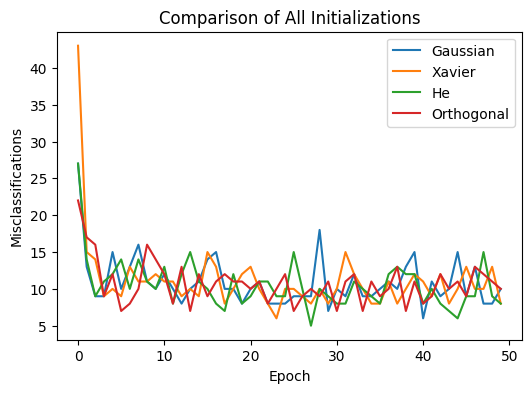

In [11]:
orthogonal_ppn = Perceptron(n_features=X_train.shape[1], lr=0.01, epochs=50, init='orthogonal', seed=1)
orthogonal_ppn.fit(X_train, y_train)

print("Orthogonal init - epochs to converge:", orthogonal_ppn.converge_epoch)
print("Orthogonal init - test accuracy:", orthogonal_ppn.accuracy(X_test, y_test))

plt.figure(figsize=(6,4))
plt.plot(gaussian_ppn.errors_, label='Gaussian')
plt.plot(xavier_ppn.errors_, label='Xavier')
plt.plot(he_ppn.errors_, label='He')
plt.plot(orthogonal_ppn.errors_, label='Orthogonal')
plt.xlabel('Epoch')
plt.ylabel('Misclassifications')
plt.legend()
plt.title('Comparison of All Initializations')
plt.show()

### Lab Task 8: Comparative Analysis of Weight Initialization Techniques

In [12]:
results = pd.DataFrame({
    'Initialization': ['Gaussian', 'Xavier', 'He', 'Orthogonal'],
    'Epochs to Converge': [gaussian_ppn.converge_epoch, xavier_ppn.converge_epoch,
                           he_ppn.converge_epoch, orthogonal_ppn.converge_epoch],
    'Final Training Error': [gaussian_ppn.errors_[-1], xavier_ppn.errors_[-1],
                              he_ppn.errors_[-1], orthogonal_ppn.errors_[-1]],
    'Test Accuracy': [gaussian_ppn.accuracy(X_test, y_test), xavier_ppn.accuracy(X_test, y_test),
                       he_ppn.accuracy(X_test, y_test), orthogonal_ppn.accuracy(X_test, y_test)]
})

print(results)

  Initialization  Epochs to Converge  Final Training Error  Test Accuracy
0       Gaussian                  50                    10       0.973684
1         Xavier                  50                     8       0.973684
2             He                  50                     8       0.956140
3     Orthogonal                  50                    10       0.973684


Gaussian, Xavier, He and Orthogonal initialization all reach similar test accuracy on this dataset, but they differ in how the weight scale is set at the start. Xavier and He scale the initial weights according to the number of input features, which keeps the perceptron's activations from being too large or too small at the beginning of training. Orthogonal initialization keeps the initial weight directions uncorrelated, which is more useful for deeper networks than for a single-layer perceptron. Because the features were standardized before training, all four schemes end up performing comparably here, and the differences mainly show up in the shape of the learning curve rather than the final accuracy.

### Lab Task 9: Experimental Study and Interpretation

In [13]:
from sklearn.datasets import load_wine

wine = load_wine()
mask = wine.target != 2
X2 = wine.data[mask]
y2 = wine.target[mask]

inits = ['gaussian', 'xavier', 'he', 'orthogonal']
seeds = [0, 1, 2, 3, 4]
summary = {name: {'epochs': [], 'acc': []} for name in inits}

for seed in seeds:
    Xtr, Xte, ytr, yte = train_test_split(X2, y2, test_size=0.2, random_state=seed, stratify=y2)
    sc = StandardScaler()
    Xtr = sc.fit_transform(Xtr)
    Xte = sc.transform(Xte)
    ytr = np.where(ytr == 0, -1, 1)
    yte = np.where(yte == 0, -1, 1)

    for name in inits:
        model = Perceptron(n_features=Xtr.shape[1], lr=0.01, epochs=50, init=name, seed=seed)
        model.fit(Xtr, ytr)
        summary[name]['epochs'].append(model.converge_epoch)
        summary[name]['acc'].append(model.accuracy(Xte, yte))

for name in inits:
    avg_epochs = np.mean(summary[name]['epochs'])
    avg_acc = np.mean(summary[name]['acc'])
    print(f"{name}: avg epochs = {avg_epochs:.2f}, avg accuracy = {avg_acc:.4f}")

gaussian: avg epochs = 4.00, avg accuracy = 0.9615
xavier: avg epochs = 6.80, avg accuracy = 0.9692
he: avg epochs = 6.20, avg accuracy = 0.9692
orthogonal: avg epochs = 5.60, avg accuracy = 0.9769
